# Preneed returns — full lump-sum guaranteed trust

The family pays the full contract price today. The funeral home guarantees the
funeral at that price, whenever death occurs. The money goes into a preneed
trust and grows. At death, the trust releases its full value to the funeral
home.

The funeral home makes money only if the trust grows faster than funeral
inflation.

**Model assumptions**
1. 100% of the contract price goes into the trust. No retainage at the sale.
2. The trustee fee applies to the full balance each year.
3. The tax applies to the yearly earnings only, not to the balance.
4. The fee and the tax do not change over the term.
5. There are no cancellations, no partial payments and no COGS change other
   than inflation.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

## 1. Assumptions

In [2]:
funeral_cost = 12_000               # contract price today, USD
funeral_yearly_inflation = 0.035    # yearly increase of the true funeral cost
trust_yearly_return = 0.055         # gross yearly return of the trust
trust_yearly_fee = 0.0075           # trustee / admin fee, on the balance
qft_effective_tax = 0.01            # effective tax rate on the yearly earnings

years = [i for i in range(0, 21)]

## 2. The model

**Cost of the funeral at time `t`** — the true cost to deliver the funeral,
inflated:

    cost(t) = funeral_cost * (1 + inflation) ** t

**Value of the trust at time `t`** — each year the trust earns the gross
return, then pays the fee on the balance and the tax on the earnings. All three
rates are constant, so the yearly steps reduce to one net rate:

    net = return - fee - (return * tax)
    trust(t) = funeral_cost * (1 + net) ** t

**Net margin at time `t`** — what the funeral home keeps:

    margin(t) = trust(t) - cost(t)

In [3]:
def cost_of_funeral_at_time(t):
    """True cost to deliver the funeral in year t."""
    return funeral_cost * (1 + funeral_yearly_inflation) ** t


# Fee comes off the balance. Tax comes off the earnings only.
trust_net_yearly_return = (
    trust_yearly_return
    - trust_yearly_fee
    - trust_yearly_return * qft_effective_tax
)


def trust_value_at_time(t):
    """Value released to the funeral home if death occurs in year t."""
    return funeral_cost * (1 + trust_net_yearly_return) ** t


def net_margin_at_time(t):
    """Payout to the funeral home, less the cost to deliver the funeral."""
    return trust_value_at_time(t) - cost_of_funeral_at_time(t)


print(f"Gross trust return:  {trust_yearly_return:>7.3%}")
print(f"Net trust return:    {trust_net_yearly_return:>7.3%}")
print(f"Funeral inflation:   {funeral_yearly_inflation:>7.3%}")
print(f"Real spread:         {trust_net_yearly_return - funeral_yearly_inflation:>7.3%}")

Gross trust return:   5.500%
Net trust return:     4.695%
Funeral inflation:    3.500%
Real spread:          1.195%


## 3. The data table

This table is the source for both charts, and it is the accessible view of
them.

In [4]:
df = pd.DataFrame({
    "year": years,
    "funeral_cost": [cost_of_funeral_at_time(t) for t in years],
    "trust_value": [trust_value_at_time(t) for t in years],
})
df["net_margin"] = df["trust_value"] - df["funeral_cost"]
df["margin_pct"] = df["net_margin"] / df["funeral_cost"]

df.style.format({
    "funeral_cost": "${:,.0f}",
    "trust_value": "${:,.0f}",
    "net_margin": "${:,.0f}",
    "margin_pct": "{:.1%}",
})

,year,funeral_cost,trust_value,net_margin,margin_pct
0,0,"$12,000","$12,000",$0,0.0%
1,1,"$12,420","$12,563",$143,1.2%
2,2,"$12,855","$13,153",$299,2.3%
3,3,"$13,305","$13,771",$466,3.5%
4,4,"$13,770","$14,417",$647,4.7%
5,5,"$14,252","$15,094",$842,5.9%
6,6,"$14,751","$15,803","$1,052",7.1%
7,7,"$15,267","$16,545","$1,277",8.4%
8,8,"$15,802","$17,322","$1,520",9.6%
9,9,"$16,355","$18,135","$1,780",10.9%


## 4. Chart style

One palette for all charts in this notebook. Blue is the neutral series colour.
Red shows a loss only.

In [5]:
SURFACE = "#fcfcfb"    # chart surface
INK = "#0b0b0b"        # primary text
INK_2 = "#52514e"      # secondary text
GRID = "#e3e2de"       # recessive gridline
BLUE = "#2a78d6"       # series 1
RED = "#e34948"        # loss

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 130,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "axes.labelsize": 10,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "axes.grid.axis": "y",
})

def dollars(v):
    """Format as currency. The backslash stops matplotlib math mode."""
    return rf"\${v:,.0f}"


DOLLARS = mticker.FuncFormatter(lambda v, _: dollars(v))

## 5. Price of the funeral over time

The contract locks the price at $12,000. This chart shows what the same funeral
costs the funeral home to deliver in each future year.

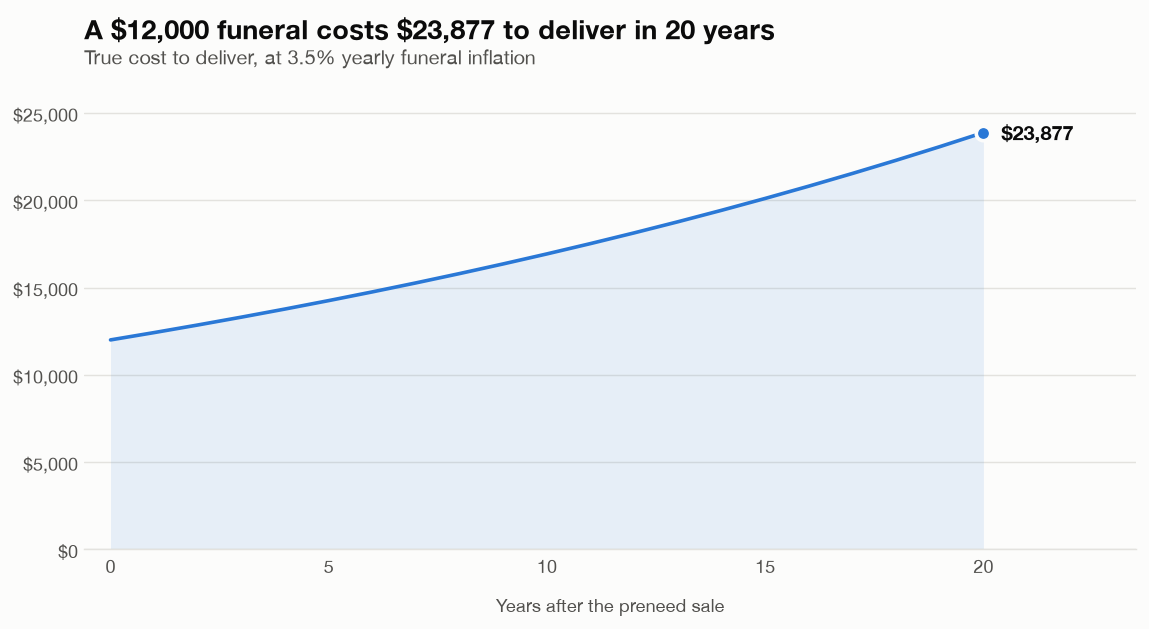

In [6]:
fig, ax = plt.subplots()

x = df["year"]
y = df["funeral_cost"]

ax.fill_between(x, y, color=BLUE, alpha=0.10, linewidth=0)
ax.plot(x, y, color=BLUE, linewidth=2, solid_capstyle="round", solid_joinstyle="round")

# End marker, with a surface ring so it stays legible over the line.
ax.plot(x.iloc[-1], y.iloc[-1], marker="o", markersize=8, color=BLUE,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)

# Label the endpoint only. The axis carries the rest.
ax.annotate(dollars(y.iloc[-1]), (x.iloc[-1], y.iloc[-1]),
            xytext=(10, 0), textcoords="offset points",
            va="center", ha="left", fontsize=11, fontweight="bold", color=INK)

ax.set_title(f"A {dollars(funeral_cost)} funeral costs {dollars(y.iloc[-1])} "
             f"to deliver in {years[-1]} years",
             fontsize=15, fontweight="bold", color=INK, loc="left", pad=24)
ax.text(0, 1.03, "True cost to deliver, at 3.5% yearly funeral inflation",
        transform=ax.transAxes, fontsize=11, color=INK_2, va="bottom", ha="left")

ax.set_xlabel("Years after the preneed sale", labelpad=10)
ax.set_ylabel("")
ax.yaxis.set_major_formatter(DOLLARS)
ax.set_xticks(range(0, 21, 5))
ax.set_xlim(-0.6, 23.5)
ax.set_ylim(0, y.max() * 1.12)
ax.xaxis.grid(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

## 6. Net margin to the funeral home

The payout is the trust value at the year of death. The margin is that payout,
less the true cost of the funeral in the same year.

Above zero, the funeral home makes money. Below zero, the guarantee costs the
funeral home money.

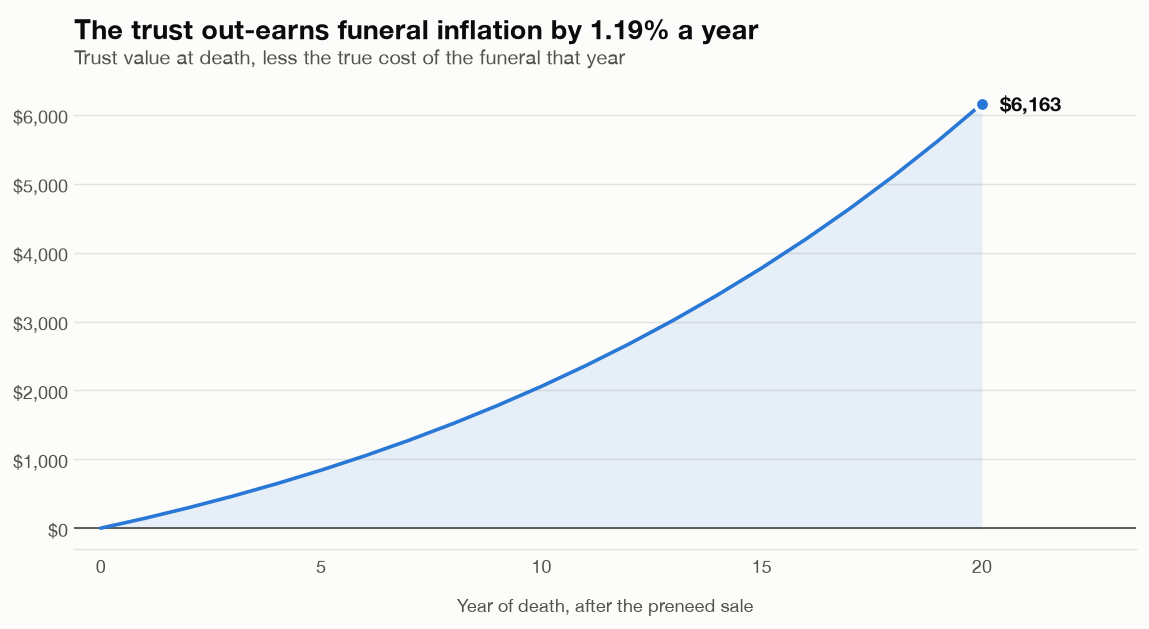

In [7]:
fig, ax = plt.subplots()

x = df["year"]
y = df["net_margin"]

# Colour the wash by sign: blue for profit, red for loss.
ax.fill_between(x, y, 0, where=(y >= 0), interpolate=True,
                color=BLUE, alpha=0.10, linewidth=0)
ax.fill_between(x, y, 0, where=(y < 0), interpolate=True,
                color=RED, alpha=0.10, linewidth=0)

ax.axhline(0, color=INK_2, linewidth=1, zorder=2)
ax.plot(x, y, color=BLUE if y.iloc[-1] >= 0 else RED, linewidth=2,
        solid_capstyle="round", solid_joinstyle="round", zorder=3)

end_color = BLUE if y.iloc[-1] >= 0 else RED
ax.plot(x.iloc[-1], y.iloc[-1], marker="o", markersize=8, color=end_color,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)

ax.annotate(dollars(y.iloc[-1]), (x.iloc[-1], y.iloc[-1]),
            xytext=(10, 0), textcoords="offset points",
            va="center", ha="left", fontsize=11, fontweight="bold", color=INK)

ax.set_title("The trust out-earns funeral inflation by %s a year"
             % f"{trust_net_yearly_return - funeral_yearly_inflation:.2%}",
             fontsize=15, fontweight="bold", color=INK, loc="left", pad=24)
ax.text(0, 1.03,
        "Trust value at death, less the true cost of the funeral that year",
        transform=ax.transAxes, fontsize=11, color=INK_2, va="bottom", ha="left")

ax.set_xlabel("Year of death, after the preneed sale", labelpad=10)
ax.set_ylabel("")
ax.yaxis.set_major_formatter(DOLLARS)
ax.set_xticks(range(0, 21, 5))
ax.set_xlim(-0.6, 23.5)
ax.xaxis.grid(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()